<a href="https://colab.research.google.com/github/rajesh045-blackhole/Gesture_app/blob/main/customer_segm_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Exploration**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

In [ ]:
df  = pd.read_csv("/content/Online Retail.csv")

In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [ ]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
76413,542625,21080,SET/20 RED RETROSPOT PAPER NAPKINS,1,1/31/11 9:50,2.46,NaN,United Kingdom
224879,556578,22334,DINOSAUR PARTY BAG + STICKER SET,8,6/13/11 14:13,1.65,12472.0,Germany
334893,566271,22960,JAM MAKING SET WITH JARS,6,9/11/11 13:44,4.25,14250.0,United Kingdom
395637,571039,21034,REX CASH+CARRY JUMBO SHOPPER,1,10/13/11 12:59,0.95,16121.0,United Kingdom
193303,553523,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,7,5/17/11 14:46,4.13,NaN,United Kingdom


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df["Quantity"].sum()

np.int64(5176450)

In [ ]:
sum(df["Quantity"]*df["UnitPrice"])

9747747.93400317

In [ ]:
df.duplicated().sum()

np.int64(5268)

#***Data Cleaning***

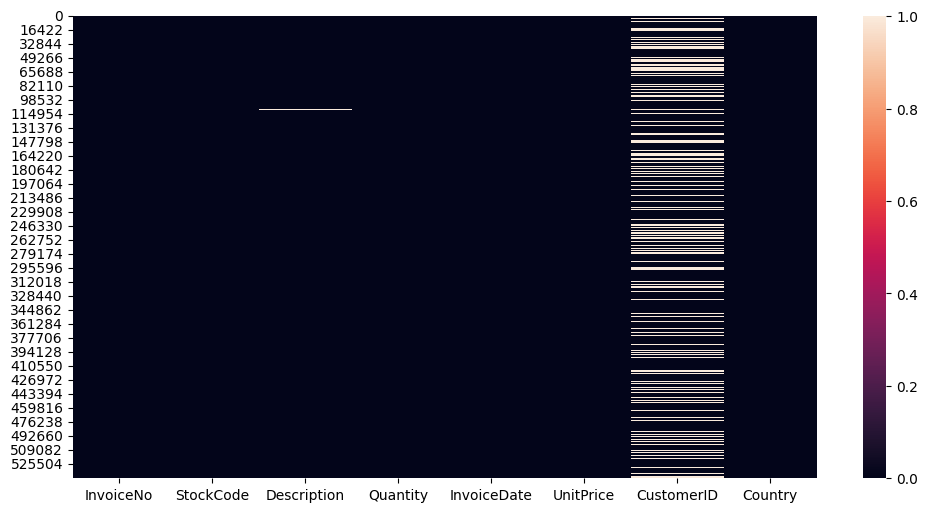

In [ ]:
missing = df.isnull()
plt.figure(figsize = (12,6))
sns.heatmap(missing)
plt.show()

In [ ]:
missing_value = df[df["CustomerID"].isnull()]

In [ ]:
missing_value.shape

(135080, 8)

In [ ]:
missing_value

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/10 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/10 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/10 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/10 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/10 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/11 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/11 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/11 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/11 10:26,10.79,NaN,United Kingdom


In [ ]:
df.dropna(subset =["CustomerID"],inplace = True)

In [ ]:
df.shape

(406829, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


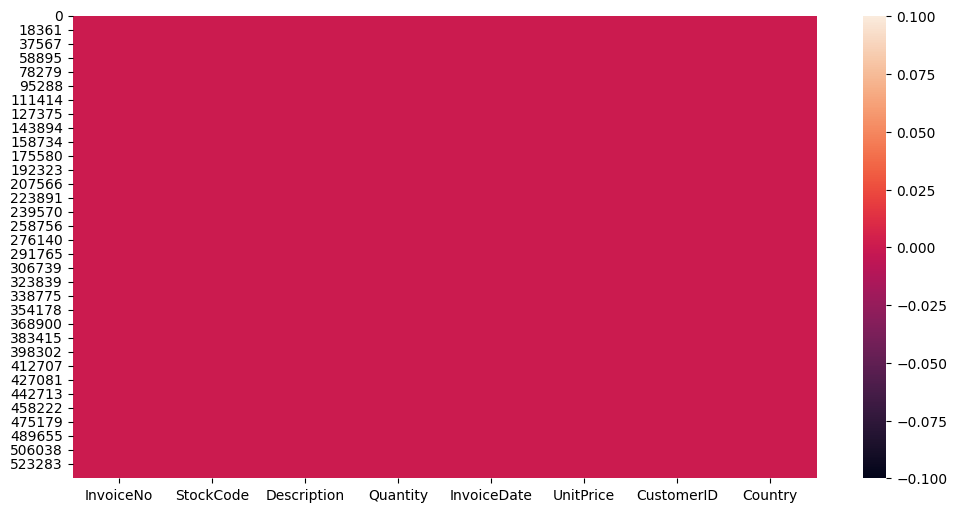

In [ ]:
missing_again = df.isnull()
plt.figure(figsize = (12,6))
sns.heatmap(missing_again)
plt.show()

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df[df["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [ ]:
df  = df[df["Quantity"]>0]

In [ ]:
df.shape

(397924, 8)

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [ ]:
df.duplicated().sum()

np.int64(5192)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


#***Data Visualization***

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [ ]:
import seaborn as sns
colors = sns.color_palette("hsv", 11)
colors

[(1.0, 0.48639754522107453, 0.0),
 (0.9882349698526169, 0.9610300602947661, 0.0),
 (0.5176455764691059, 1.0, 0.0),
 (0.03124934374934376, 1.0, 1.3125013124790507e-06),
 (0.0, 1.0, 0.45514704029421543),
 (0.0, 1.0, 0.9647031631761764),
 (0.0, 0.5488995139730435, 1.0),
 (0.0, 0.062501968751969, 1.0),
 (0.44705736433677606, 0.0, 1.0),
 (0.9334549095578512, 0.0, 1.0),
 (1.0, 0.0, 0.5801475452210745)]

In [ ]:
len(df["Country"].unique())

37

/tmp/ipython-input-39-986959354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=country_data, x='Country', y='InvoiceCount', palette=colors)


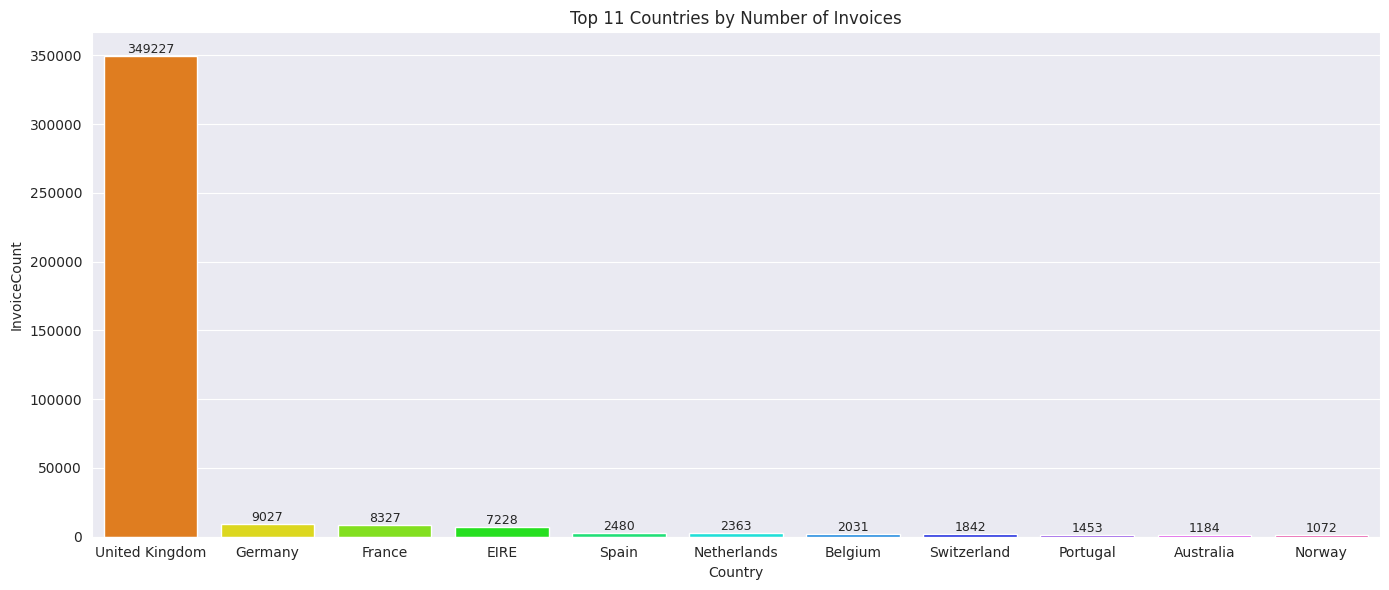

In [ ]:
# Step 1: Count invoices per country
country_data = df['Country'].value_counts().nlargest(11).reset_index()
country_data.columns = ['Country', 'InvoiceCount']

# Step 2: Plot
plt.figure(figsize=(14, 6))
sns.set_style("darkgrid")
colors = sns.color_palette("hsv", 11)  # Auto 11 distinct colors

barplot = sns.barplot(data=country_data, x='Country', y='InvoiceCount', palette=colors)

# Step 3: Add value labels
for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.title("Top 11 Countries by Number of Invoices")
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(392732, 8)

In [ ]:
countryss = df.groupby("Country").size().reset_index(name="Count")
countryss

,Country,Count
0,Australia,1184
1,Austria,398
2,Bahrain,17
3,Belgium,2031
4,Brazil,32
5,Canada,151
6,Channel Islands,747
7,Cyprus,603
8,Czech Republic,25
9,Denmark,380


In [ ]:
countryss.sort_values(by="Count", ascending=False, inplace=True)
countryss

,Country,Count
35,United Kingdom,349227
14,Germany,9027
13,France,8327
10,EIRE,7228
30,Spain,2480
23,Netherlands,2363
3,Belgium,2031
32,Switzerland,1842
26,Portugal,1453
0,Australia,1184


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Now extract month
df["Month"] = df["InvoiceDate"].dt.month
df["Month"].value_counts()

,count
Month,
11,63182
10,48796
12,42699
9,39671
5,28075
6,26926
3,26872
8,26796
7,26582


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12


In [ ]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month
117577,546392,22139,RETROSPOT TEA SET CERAMIC 11 PC,6,2011-03-11 14:15:00,4.95,14587.0,United Kingdom,3
143245,548670,20727,LUNCH BAG BLACK SKULL.,4,2011-04-01 15:37:00,1.65,15356.0,United Kingdom,4
371836,569228,20696,FLORAL SOFT CAR TOY,3,2011-10-02 14:47:00,3.75,15547.0,United Kingdom,10
469424,576593,23198,PANTRY MAGNETIC SHOPPING LIST,2,2011-11-15 14:48:00,1.45,15720.0,United Kingdom,11
328431,565769,21293,MIRRORED DOVE WALL DECORATION,6,2011-09-06 14:32:00,2.10,16175.0,United Kingdom,9


In [ ]:
df["Month"].unique()

array([12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [ ]:
len(df["Month"].unique())

12

/tmp/ipython-input-58-3917515129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = month_data, x = "Month",y = "InvoiceNo",ax = axes,linewidth=1,edgecolor = "0.2",palette=colorr)


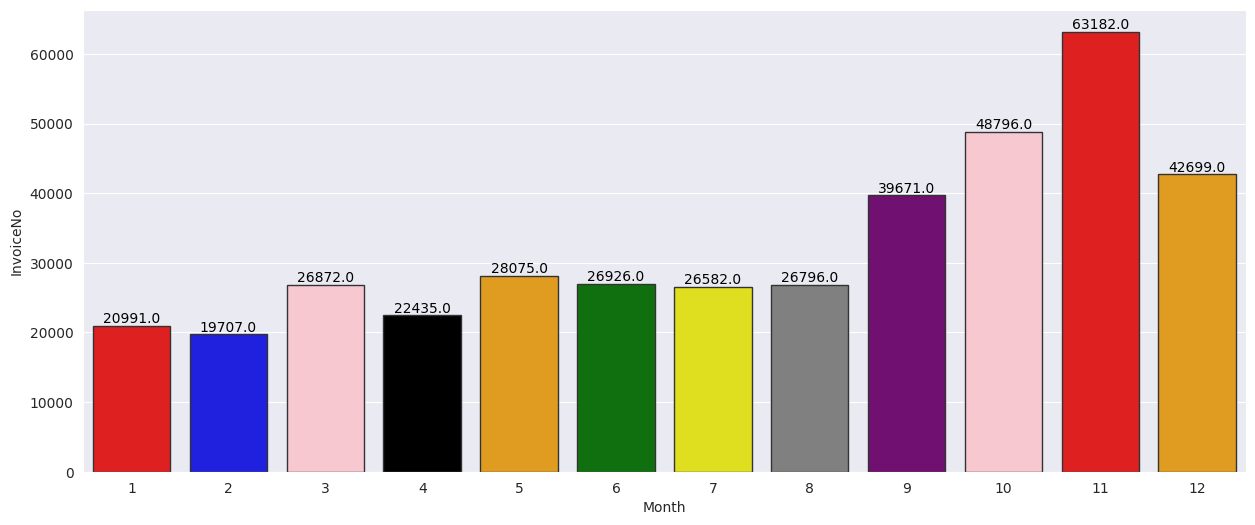

In [ ]:
month_data = df.groupby("Month").count().reset_index()
fig,axes = plt.subplots(figsize = (15,6))
sns.set_style("darkgrid")
colorr = ["red","blue","pink","black","orange","green","yellow","grey","purple","pink","red","orange"]
sns.barplot(data = month_data, x = "Month",y = "InvoiceNo",ax = axes,linewidth=1,edgecolor = "0.2",palette=colorr)

for p in axes.patches:
    axes.annotate(f"{p.get_height()}",
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Position
                ha='center', va='bottom', fontsize=10, color='black',fontweight='light')
plt.show()

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month'],
      dtype='object')

In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12


In [ ]:
df["MontaryValue"] = df.apply(lambda x:x["Quantity"]*x["UnitPrice"] ,axis =1)

In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,MontaryValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34


In [ ]:
df2 = df

In [ ]:
df  = df2.drop(["InvoiceNo","StockCode",	"Description","InvoiceDate","Country"],axis =1 )

In [ ]:
df.head()

,Quantity,UnitPrice,CustomerID,Month,MontaryValue
0,6,2.55,17850.0,12,15.30
1,6,3.39,17850.0,12,20.34
2,8,2.75,17850.0,12,22.00
3,6,3.39,17850.0,12,20.34
4,6,3.39,17850.0,12,20.34


In [ ]:
cutomer_data = df.groupby("CustomerID").sum()

[]

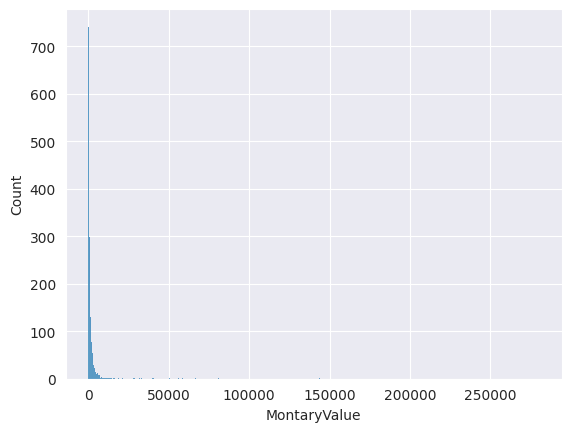

In [ ]:
sns.histplot(cutomer_data["MontaryValue"])
plt.plot()

In [ ]:
cutomer_data.sort_values(by = "MontaryValue")

,Quantity,UnitPrice,Month,MontaryValue
CustomerID,,,,
13256.0,12540,0.00,11,0.00
16738.0,3,1.25,2,3.75
14792.0,2,6.20,20,6.20
16454.0,3,3.95,20,6.90
17956.0,1,12.75,4,12.75
...,...,...,...,...
14911.0,80490,26150.35,46178,143711.17
16446.0,80997,4.98,22,168472.50
17450.0,69973,1135.32,2284,194390.79


In [ ]:
cutomer_data[cutomer_data["MontaryValue"]==0.00]

,Quantity,UnitPrice,Month,MontaryValue
CustomerID,,,,
13256.0,12540,0.0,11,0.0


In [ ]:
cutomer_data

,Quantity,UnitPrice,Month,MontaryValue
CustomerID,,,,
12346.0,74215,1.04,1,77183.60
12347.0,2458,481.21,1383,4310.00
12348.0,2341,178.71,257,1797.24
12349.0,631,605.10,803,1757.55
12350.0,197,65.30,34,334.40
...,...,...,...,...
18280.0,45,47.65,30,180.60
18281.0,54,39.36,42,80.82
18282.0,103,62.39,116,178.05


In [ ]:
cutomer_data.columns

Index(['Quantity', 'UnitPrice', 'Month', 'MontaryValue'], dtype='object')

In [ ]:
cutomer_data.drop(['Quantity', 'UnitPrice', 'Month'],axis =1 ,inplace =True)

In [ ]:
cutomer_data

,MontaryValue
CustomerID,
12346.0,77183.60
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,178.05


In [ ]:
cutomer_data["Frequency"] = df.groupby("CustomerID")["MontaryValue"].count().values

In [ ]:
cutomer_data

,MontaryValue,Frequency
CustomerID,,
12346.0,77183.60,1
12347.0,4310.00,182
12348.0,1797.24,31
12349.0,1757.55,73
12350.0,334.40,17
...,...,...
18280.0,180.60,10
18281.0,80.82,7
18282.0,178.05,12


[]

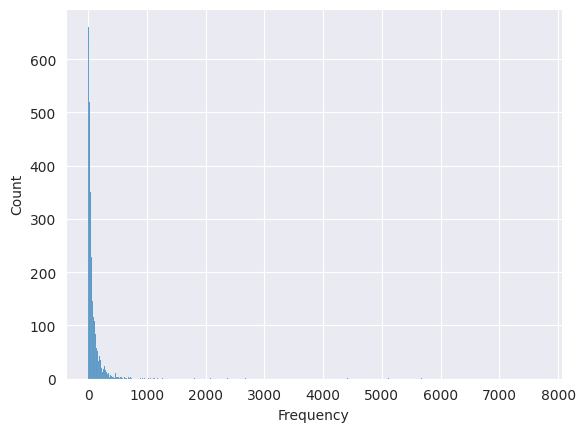

In [ ]:
sns.histplot(cutomer_data["Frequency"])
plt.plot()

In [ ]:
cutomer_data.sort_values(by = "Frequency",ascending = False)

,MontaryValue,Frequency
CustomerID,,
17841.0,40519.84,7676
14911.0,143711.17,5672
14096.0,65164.79,5111
12748.0,33053.19,4413
14606.0,12076.15,2677
...,...,...
13302.0,63.75,1
15940.0,35.80,1
14705.0,179.00,1


In [ ]:
cutomer_data[cutomer_data["Frequency"]==2].count()

,0
MontaryValue,53
Frequency,53


In [ ]:
df.head()

,Quantity,UnitPrice,CustomerID,Month,MontaryValue
0,6,2.55,17850.0,12,15.30
1,6,3.39,17850.0,12,20.34
2,8,2.75,17850.0,12,22.00
3,6,3.39,17850.0,12,20.34
4,6,3.39,17850.0,12,20.34


In [ ]:
df2.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month', 'MontaryValue'],
      dtype='object')

In [ ]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,MontaryValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34


In [ ]:
df2.shape

(392732, 10)

In [ ]:
max(df2["InvoiceDate"])

Timestamp('2011-12-09 12:50:00')

In [ ]:
min(df2["InvoiceDate"])

Timestamp('2010-12-01 08:26:00')

In [ ]:
last_date = date(2011,12,10)

In [ ]:
df2["Recency"] = df2["InvoiceDate"].apply(lambda x: (last_date - pd.to_datetime(x).date()).days)

In [ ]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,MontaryValue,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30,374
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,374
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00,374
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,374
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,374


In [ ]:
cutomer_data["Recency"] = df2.groupby("CustomerID")["Recency"].min().values

In [ ]:
cutomer_data.head()

,MontaryValue,Frequency,Recency
CustomerID,,,
12346.0,77183.60,1,326
12347.0,4310.00,182,3
12348.0,1797.24,31,76
12349.0,1757.55,73,19
12350.0,334.40,17,311


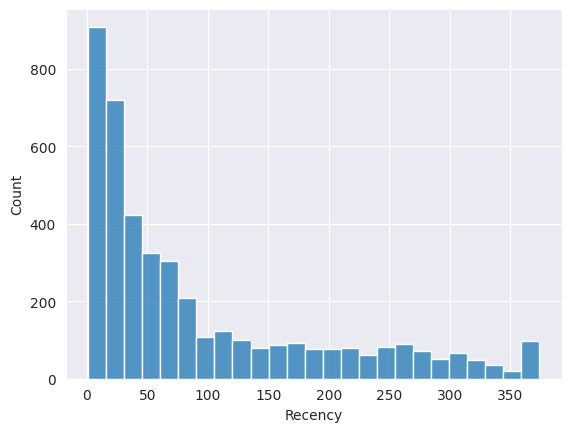

In [ ]:
sns.histplot(cutomer_data["Recency"])
plt.show()

In [ ]:
cutomer_data.columns

Index(['MontaryValue', 'Frequency', 'Recency'], dtype='object')

In [ ]:
cutomer_data["Frequency"] = cutomer_data["Frequency"].apply(lambda x:np.log(x+1))
cutomer_data["MontaryValue"] = cutomer_data["MontaryValue"].apply(lambda x:np.log(x+1))
cutomer_data["Recency"] = cutomer_data["Recency"].apply(lambda x:np.log(x+1))

In [ ]:
cutomer_data

,MontaryValue,Frequency,Recency
CustomerID,,,
12346.0,11.253955,0.693147,5.789960
12347.0,8.368925,5.209486,1.386294
12348.0,7.494564,3.465736,4.343805
12349.0,7.472245,4.304065,2.995732
12350.0,5.815324,2.890372,5.743003
...,...,...,...
18280.0,5.201806,2.397895,5.631212
18281.0,4.404522,2.079442,5.204007
18282.0,5.187665,2.564949,2.197225


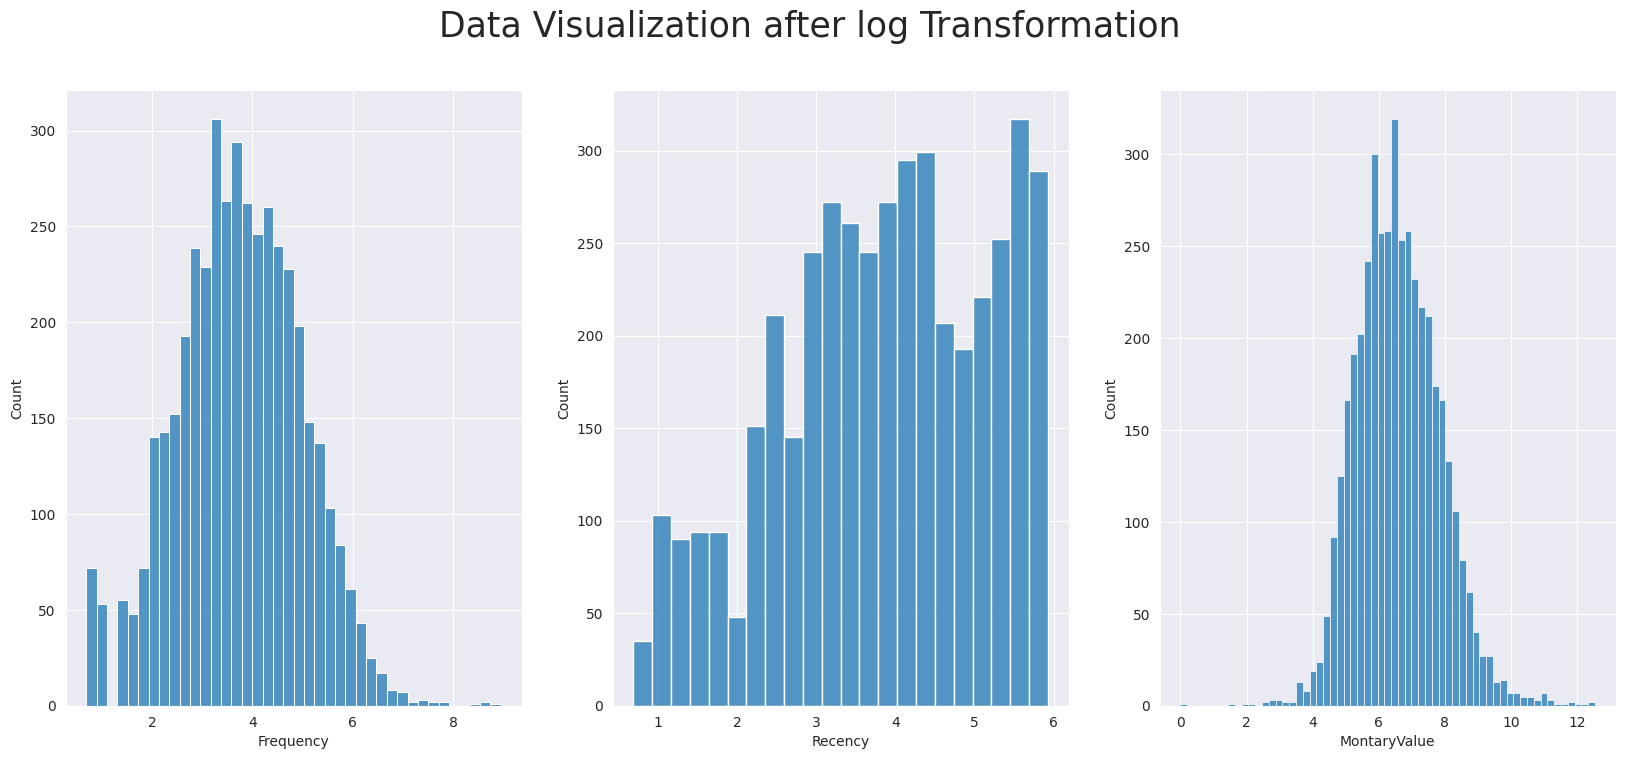

In [ ]:
fig, axis = plt.subplots(figsize = (20, 8),nrows = 1, ncols = 3)
sns.histplot(cutomer_data["Frequency"], ax = axis[0])
sns.histplot(cutomer_data["Recency"], ax = axis[1])
sns.histplot(cutomer_data["MontaryValue"], ax = axis[2])
fig.suptitle("Data Visualization after log Transformation ",size =25)
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
import plotly.express as px
fig = px.scatter_3d(cutomer_data, x = "Recency", y = "Frequency", z = "MontaryValue")
fig.show()

In [ ]:
data = pd.DataFrame(cutomer_data)
data

,MontaryValue,Frequency,Recency
CustomerID,,,
12346.0,11.253955,0.693147,5.789960
12347.0,8.368925,5.209486,1.386294
12348.0,7.494564,3.465736,4.343805
12349.0,7.472245,4.304065,2.995732
12350.0,5.815324,2.890372,5.743003
...,...,...,...
18280.0,5.201806,2.397895,5.631212
18281.0,4.404522,2.079442,5.204007
18282.0,5.187665,2.564949,2.197225


In [ ]:
data = data.loc[:,["MontaryValue",	"Frequency"	,"Recency"]]
data

,MontaryValue,Frequency,Recency
CustomerID,,,
12346.0,11.253955,0.693147,5.789960
12347.0,8.368925,5.209486,1.386294
12348.0,7.494564,3.465736,4.343805
12349.0,7.472245,4.304065,2.995732
12350.0,5.815324,2.890372,5.743003
...,...,...,...
18280.0,5.201806,2.397895,5.631212
18281.0,4.404522,2.079442,5.204007
18282.0,5.187665,2.564949,2.197225


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
sse = []
for k in range(1,11):
  kmean = KMeans(n_clusters = k,random_state =42)
  kmean.fit_predict(data)
  sse.append(kmean.inertia_)

In [ ]:
sse

[21055.575842092345,
 11010.264239904118,
 8539.186445385563,
 6955.930200541551,
 6072.642463902832,
 5269.124921364025,
 4810.875000926628,
 4435.111483290288,
 4122.107133308664,
 3894.9844055506883]

In [ ]:
n_c = range(1,11)
n_c

range(1, 11)

In [ ]:
len(n_c)

10

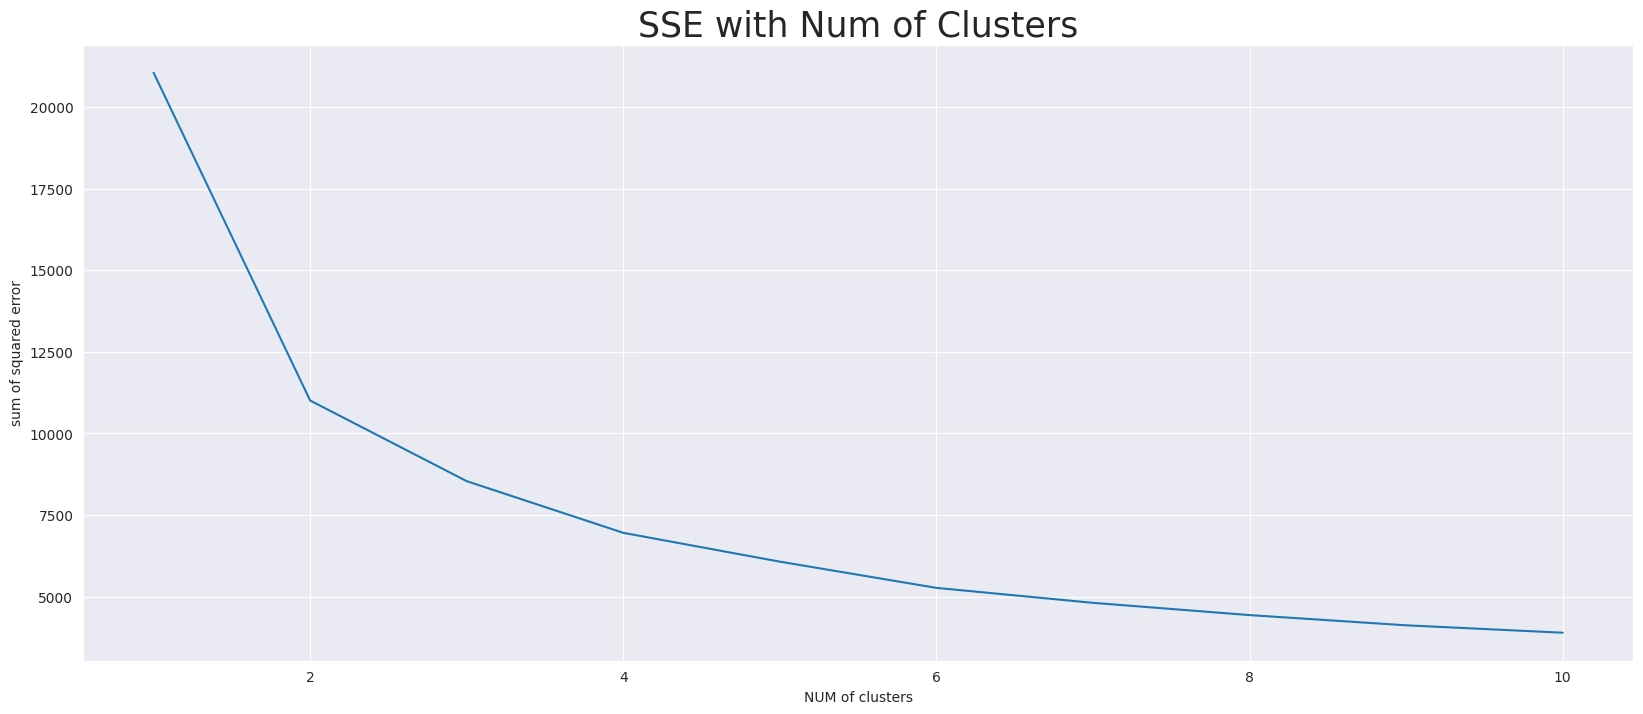

In [ ]:
plt.figure(figsize= (20,8))
plt.title("SSE with Num of Clusters" , size = 25)
plt.xlabel("NUM of clusters")
plt.ylabel("sum of squared error")
plt.plot(n_c,sse)
plt.show()

In [ ]:
km = KMeans(n_clusters=4,random_state=42)
cluster_label = km.fit_predict(data)


In [ ]:
cluster_label.shape

(4339,)

In [ ]:
d1 = [[11.253955,0.693147,5.789960]]
d = pd.DataFrame(d1,columns=data.columns)
km.predict(d1)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



array([3], dtype=int32)

In [ ]:
cutomer_data["cluter"] = cluster_label

In [ ]:
cutomer_data

,MontaryValue,Frequency,Recency,cluter
CustomerID,,,,
12346.0,11.253955,0.693147,5.789960,3
12347.0,8.368925,5.209486,1.386294,1
12348.0,7.494564,3.465736,4.343805,3
12349.0,7.472245,4.304065,2.995732,1
12350.0,5.815324,2.890372,5.743003,2
...,...,...,...,...
18280.0,5.201806,2.397895,5.631212,2
18281.0,4.404522,2.079442,5.204007,2
18282.0,5.187665,2.564949,2.197225,0


In [ ]:
cluster_data  = cutomer_data.groupby('cluter').mean()

In [ ]:
cluster_data

,MontaryValue,Frequency,Recency
cluter,,,
0,6.116732,3.377765,2.894020
1,8.187951,5.265864,2.338993
2,5.438335,2.516566,5.082441
3,7.035881,4.203582,4.345991


In [ ]:
cluster_data = cluster_data.applymap(np.exp)
cluster_data = cluster_data.applymap(int)

/tmp/ipython-input-115-2615582773.py:1: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/tmp/ipython-input-115-2615582773.py:2: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [ ]:
cluster_data

,MontaryValue,Frequency,Recency
cluter,,,
0,453,29,18
1,3597,193,10
2,230,12,161
3,1136,66,77


In [ ]:
# import pickle
# pickle_out = open("km1.pkl", "wb")
# pickle.dump(km, pickle_out)
# pickle_out.close()
# specific_values = [[404, 4, 12]]
# predicted_cluster = km.predict(specific_values)
# predicted_cluster


In [ ]:
# from google.colab import files
# files.download('km.pkl')

In [ ]:
# import joblib
# joblib.dump(km, 'kmeans_model4.pkl')
# from google.colab import files
# files.download('kmeans_model4.pkl')